## 2025년 농번기 인력 지원대책 PDF 파일 데이터 분석

2025년 기준 대한민국의 농번기 인력에 대한 내용을 분석하고, 
예상되는 Labor_cost 를 예측하여, 농촌에 부족한 인력 대체 가능성 및 
농업 로봇 투입시 해당 문제를 해결할 수 있는지를 간접적으로 계산.

 - 데이터 구조화 : (2025년)_농번기_인력_지원대책_농번기(4∼6월,_9∼10월)_농업_고용인력의_적기·적정_공급으로_‘25년_농산물의_안정적_생산·공급_지원 <- 파일은 PDF 파일로 되어있으며  
   
   1) 가로로 길게 늘어진 2차원 매트릭스 표 (품목/농작업 x 1월~12월)로 구성
    -> Long Format 형태로 변환. 
    -> column 구조 : 품목(Crop),농작업(Operation), 월(Month), 인력수요_만명(Demand)
   2) 농작업별 일의 형태 및 임금 단가 매칭 규칙 설정
    -> 전정(Prunning) : 전문기술 필요 -> 상용/임시직 비중 높을 것으로 예상 -> 고임금군 : 일당 15만원
    -> 적과(Thinning) : 섬세한 반복 작업 -> 임시/일용직 중심 -> 중임금군 : 일당 12만원선
    -> 수확(Harvesting) : 단기 고강도 -> 단기 일용직 집중 -> 상임금군 : 일단 14만원선

    

In [1]:
import sys
print(sys.executable)

c:\Users\msm03\AppData\Local\Programs\Python\Python312\python.exe


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False

In [3]:
raw_records = [
    # 1. 사과 (총 3개 작업)
    {"crop": "사과", "operation": "전정", "monthly_demand": [7, 22, 16, 0, 0, 1, 0, 0, 0, 0, 0, 1]},
    {"crop": "사과", "operation": "적과", "monthly_demand": [0, 0, 0, 8, 60, 28, 2, 0, 0, 0, 0, 0]},
    {"crop": "사과", "operation": "수확", "monthly_demand": [0, 0, 0, 0, 0, 0, 3, 4, 21, 37, 39, 2]},
    
    # 2. 복숭아 (총 4개 작업)
    {"crop": "복숭아", "operation": "전정", "monthly_demand": [0, 24, 12, 7, 4, 0, 0, 0, 0, 0, 0, 0]},
    {"crop": "복숭아", "operation": "적과", "monthly_demand": [0, 0, 0, 9, 34, 8, 2, 2, 0, 0, 0, 0]},
    {"crop": "복숭아", "operation": "봉지씌우기", "monthly_demand": [0, 0, 0, 0, 6, 37, 8, 1, 0, 0, 0, 0]},
    {"crop": "복숭아", "operation": "수확", "monthly_demand": [0, 0, 0, 0, 0, 10, 13, 16, 11, 3, 0, 0]},
    
    # 3. 마늘 (총 2개 작업)
    {"crop": "마늘", "operation": "수확", "monthly_demand": [0, 0, 0, 2, 27, 47, 2, 0, 0, 0, 1, 0]},
    {"crop": "마늘", "operation": "파종", "monthly_demand": [0, 0, 0, 0, 0, 0, 0, 3, 19, 29, 18, 0]},
    
    # 4. 고추 (총 2개 작업)
    {"crop": "고추", "operation": "정식", "monthly_demand": [0, 2, 5, 24, 25, 2, 0, 1, 4, 1, 0, 0]},
    {"crop": "고추", "operation": "수확", "monthly_demand": [0, 1, 1, 1, 1, 4, 11, 25, 20, 8, 1, 1]},
    
    # 5. 포도 (총 4개 작업)
    {"crop": "포도", "operation": "순지르기", "monthly_demand": [0, 0, 3, 9, 7, 2, 1, 0, 0, 0, 0, 0]},
    {"crop": "포도", "operation": "알솎기", "monthly_demand": [0, 0, 0, 3, 15, 15, 0, 0, 0, 0, 0, 0]},
    {"crop": "포도", "operation": "봉지씌우기", "monthly_demand": [0, 0, 0, 0, 3, 17, 6, 0, 0, 0, 0, 0]},
    {"crop": "포도", "operation": "수확", "monthly_demand": [0, 0, 0, 0, 0, 2, 6, 8, 9, 5, 0, 0]},
    
    # 6. 양파 (총 2개 작업)
    {"crop": "양파", "operation": "수확", "monthly_demand": [0, 0, 0, 6, 15, 31, 3, 0, 0, 1, 0, 0]},
    {"crop": "양파", "operation": "정식", "monthly_demand": [0, 0, 0, 0, 0, 1, 1, 0, 3, 24, 25, 0]},
    
    # 7. 감자 (총 2개 작업)
    {"crop": "감자", "operation": "파종", "monthly_demand": [0, 2, 15, 13, 4, 1, 0, 1, 4, 1, 1, 1]},
    {"crop": "감자", "operation": "수확", "monthly_demand": [0, 1, 1, 2, 6, 15, 9, 11, 2, 1, 5, 1]},
    
    # 8. 배 (총 4개 작업)
    {"crop": "배", "operation": "수분", "monthly_demand": [0, 0, 1, 14, 3, 0, 0, 0, 0, 0, 0, 0]},
    {"crop": "배", "operation": "적과", "monthly_demand": [0, 0, 0, 2, 17, 2, 0, 0, 0, 0, 0, 0]},
    {"crop": "배", "operation": "봉지씌우기", "monthly_demand": [0, 0, 0, 1, 5, 15, 1, 0, 0, 0, 0, 0]},
    {"crop": "배", "operation": "수확", "monthly_demand": [0, 0, 0, 0, 0, 0, 0, 2, 9, 10, 4, 0]},
    
    # 9. 배추 (총 2개 작업)
    {"crop": "배추", "operation": "정식", "monthly_demand": [0, 0, 2, 3, 2, 5, 3, 9, 13, 1, 0, 0]},
    {"crop": "배추", "operation": "수확", "monthly_demand": [1, 2, 1, 0, 1, 4, 3, 5, 3, 5, 14, 3]},
    
    # 10. 무 (총 2개 작업)
    {"crop": "무", "operation": "파종", "monthly_demand": [0, 0, 0, 0, 3, 1, 1, 6, 6, 1, 0, 0]},
    {"crop": "무", "operation": "수확", "monthly_demand": [2, 3, 3, 3, 0, 0, 0, 4, 0, 3, 6, 5]}
]

In [4]:
# 가로 매트릭스 구조를 분석용 long-Format 데이터 프레임으로 전개
flattened_data = []
for record in raw_records:
    for month_idx,demand in enumerate(record["monthly_demand"]):
        month = month_idx +1
        flattened_data.append({
            "crop":record["crop"],
            "operation":record["operation"],
            "month":month,
            "demand_ten_thousand":demand
        })

df_all = pd.DataFrame(flattened_data)
df_all

,crop,operation,month,demand_ten_thousand
0,사과,전정,1,7
1,사과,전정,2,22
2,사과,전정,3,16
3,사과,전정,4,0
4,사과,전정,5,0
...,...,...,...,...
319,무,수확,8,4
320,무,수확,9,0
321,무,수확,10,3
322,무,수확,11,6


In [18]:
# 일의 형태 분류 및 단가 매핑 모델링 - 정의는 맨 위에 써놓은 형태의 임금

def business_rule_classifier(operation):
    if operation in ['전정','수분','알솎기','순지르기']:
        return "전문기술직 (상용/단기)",150000
    elif operation in ["수확","파종"]:
        return "일반고강도직",135000
    elif operation in ['적과','봉지씌우기','정식']:
        return "일반반복직(임시/계절)", 120000
    else:
        return "기타작업", 125000
    
# 규칙적용
df_all[['work_type','daily_wage']] = df_all['operation'].apply(lambda x: pd.Series(business_rule_classifier(x)))

# 전체 임금 예측 계산(수요 만명 * 10,000 * 일당 단가)/1억 
df_all["predicted_wage_billion"] = (df_all['demand_ten_thousand']*10000*df_all['daily_wage']) / 100000000

df_all[["operation","crop"]]

,operation,crop
0,전정,사과
1,전정,사과
2,전정,사과
3,전정,사과
4,전정,사과
...,...,...
319,수확,무
320,수확,무
321,수확,무
322,수확,무


In [ ]:
# 정렬 및 다차원 집계분석
# 구축된 전체 데이터를 기준으로 품목별, 일의 형태별, 전체 총액별 정렬 및 결과를 산출

# 1. 품목별 + 농작업별 총 예측 임금 규모 순서로 정렬
df_crop_op_sorted = df_all.groupby(['crop', 'operation', 'work_type']).agg(
    total_demand_ten_thousand=('demand_ten_thousand', 'sum'),
    total_wage_predicted_billion=('predicted_wage_billion', 'sum')
).reset_index().sort_values(by='total_wage_predicted_billion', ascending=False)

print("=== [1] 품목별/농작업별 예측 임금 규모 상위 정렬 ===")
print(df_crop_op_sorted.head(10).to_string(index=False))

# 2. 예상되는 카테고리(일의 형태)별 전체 임금 예측 집계
df_category_summary = df_all.groupby('work_type').agg(
    category_demand_ten_thousand=('demand_ten_thousand', 'sum'),
    category_wage_billion=('predicted_wage_billion', 'sum')
).reset_index().sort_values(by='category_wage_billion', ascending=False)

print("\n=== [2] 카테고리(일의 형태)별 전체 임금 예측 및 정렬 ===")
print(df_category_summary.to_string(index=False))

# 3. 대한민국 10대 품목 전체 농번기 노동 임금 시장 규모 예측 총액
total_market_wage_billion = df_all['predicted_wage_billion'].sum()
print(f"\n★ [3] 10대 품목 전체 노동 임금 예측 총액: {total_market_wage_billion:.1f} 억 원")

=== [1] 품목별/농작업별 예측 임금 규모 상위 정렬 ===
crop operation     work_type  total_demand_ten_thousand  total_wage_predicted_billion
  사과        수확        일반고강도직                        106                        1431.0
  사과        적과  일반반복직(임시/계절)                         98                        1176.0
  마늘        수확        일반고강도직                         79                        1066.5
  고추        수확        일반고강도직                         74                         999.0
  마늘        파종        일반고강도직                         69                         931.5
  고추        정식  일반반복직(임시/계절)                         64                         768.0
  양파        수확        일반고강도직                         56                         756.0
  감자        수확        일반고강도직                         54                         729.0
 복숭아        수확        일반고강도직                         53                         715.5
  사과        전정 전문기술직 (상용/단기)                         47                         705.0

=== [2] 카테고리(일의 형

<Figure size 1400x600 with 0 Axes>

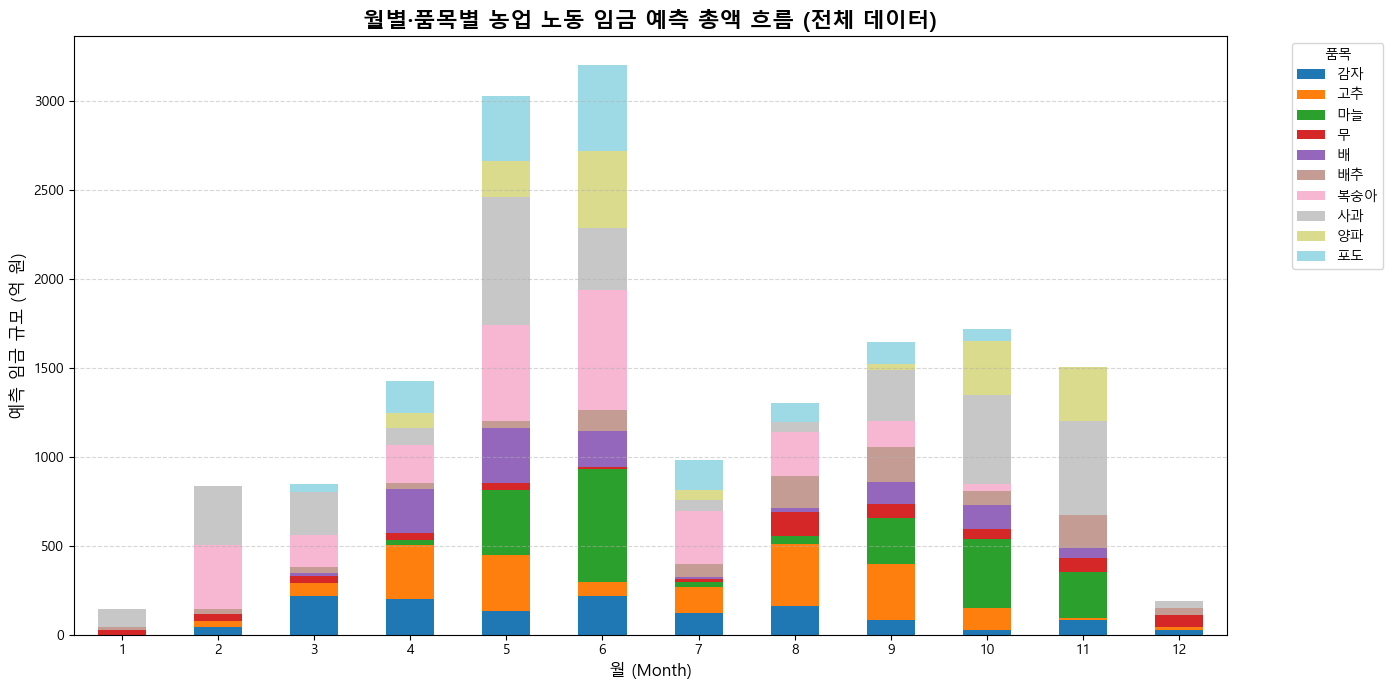

In [26]:
plt.figure(figsize=(14, 6))
# 12개월 전체 월별 트렌드를 피벗하여 시각화
df_monthly_pivot = df_all.pivot_table(index='month', columns='crop', values='predicted_wage_billion', aggfunc='sum')
df_monthly_pivot.plot(kind='bar', stacked=True, figsize=(14, 7), cmap='tab20')

plt.title('월별·품목별 농업 노동 임금 예측 총액 흐름 (전체 데이터)', fontsize=16, fontweight='bold')
plt.xlabel('월 (Month)', fontsize=12)
plt.ylabel('예측 임금 규모 (억 원)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='품목', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\msm03\AppData\Local\Temp\ipykernel_11020\1088869062.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


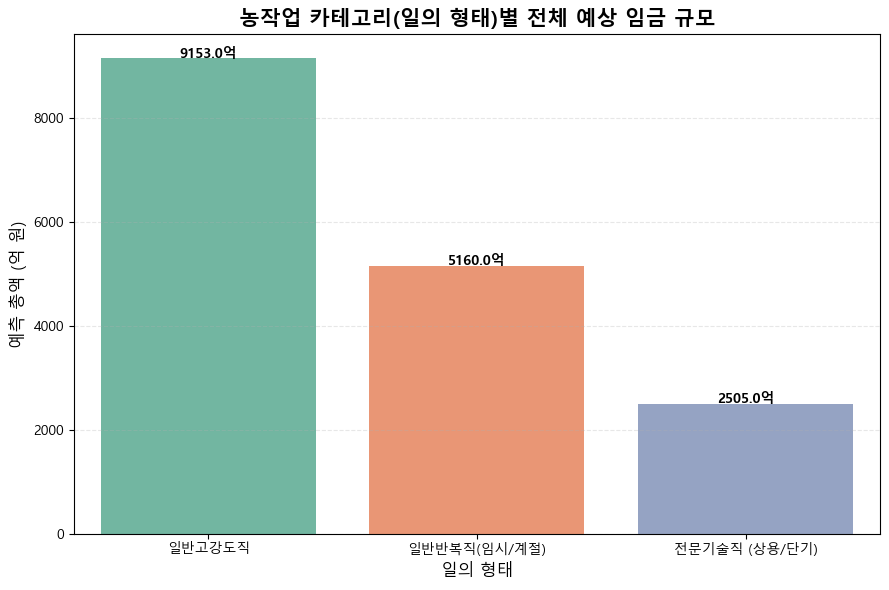

In [27]:
# 일의 형태(카테고리 별 누적 비용 비중 분석)
plt.figure(figsize=(9, 6))
sns.barplot(
    data=df_category_summary, 
    x='work_type', 
    y='category_wage_billion', 
    palette='Set2'
)
plt.title('농작업 카테고리(일의 형태)별 전체 예상 임금 규모', fontsize=15, fontweight='bold')
plt.xlabel('일의 형태', fontsize=12)
plt.ylabel('예측 총액 (억 원)', fontsize=12)
for index, row in df_category_summary.iterrows():
    plt.text(index, row['category_wage_billion'] + 5, f"{row['category_wage_billion']:.1f}억", color='black', ha="center", fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()